# Exploring the MMSP 2026 VTM Results

This notebook reproduces the VTM video coding experiments presented in the MMSP 2026 paper 🌐 *ApproxSSIMate: Fast SSIM Estimation from MSE for Image and Video Coding*.

The experiments use the VVC reference encoder VTM to encode the Objective-1-fast dataset across a range of QP values. ApproxSSIMate is then used to estimate sequence-level SSIM from MSE and reference-derived statistics, allowing both frame-level and pooled approximations to be compared directly against measured SSIM.

It walks through the main steps needed to reproduce the results, from preparing and encoding the test sequences to computing MSE, measured SSIM, and ApproxSSIMate estimates.

## Table of Contents

- [1. Setup](#1-setup)
- [2. VTM configuration](#2-vtm-configuration)
- [3. Encode the test sequences](#3-encode-the-test-sequences)
- [4. Compute reference statistics](#4-compute-reference-statistics)
- [5. Decode VTM bitstreams](#5-decode-vtm-bitstreams)
- [6. Compute MSE](#6-compute-mse)
- [7. Compute measured SSIM](#7-compute-measured-ssim)
- [8. Compute ApproxSSIMate estimates](#8-compute-approxssimate-estimates)
- [9. Compare measured and estimated SSIM](#9-compare-measured-and-estimated-ssim)
- [10. Approximation error distribution](#10-approximation-error-distribution)

## 1. Setup

Import the required Python packages and define the paths and experiment parameters used throughout the notebook.

The experiment uses all 30 Objective-1-fast sequences, each containing 60 frames, and encodes them at VTM QP values 24, 28, 32, 36, 40, and 44.

In [1]:
# To install ApproxSSIMate, uncomment and run:
# %pip install -e ..

from pathlib import Path
import subprocess

import av
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
from skimage.metrics import structural_similarity
from tqdm import tqdm
from tqdm_joblib import tqdm_joblib

from approxssimate import (
    approx_ssim_from_k_mse,
    compute_k,
    read_k_file,
    read_mse_file,
    write_k_file,
    write_mse_file,
)

ROOT = Path(".")
DATA_DIR = ROOT / "data"
SOURCE_DIR = Path.home() / "Datasets" / "objective-1-fast"

ENCODE_DIR = DATA_DIR / "encodes"
VTM_ENCODE_DIR = ENCODE_DIR / "vtm"
YUV_DIR = ENCODE_DIR / "yuv"

RESULTS_DIR = DATA_DIR / "results"
K_DIR = RESULTS_DIR / "k"
MSE_DIR = RESULTS_DIR / "mse" / "vtm"
RECON_DIR = RESULTS_DIR / "recon" / "vtm"

QPS = [24, 28, 32, 36, 40, 44]
FRAMES = 60
N_JOBS = 4

for path in (
    VTM_ENCODE_DIR,
    YUV_DIR,
    K_DIR,
    MSE_DIR,
    RECON_DIR,
):
    path.mkdir(parents=True, exist_ok=True)

sources = sorted(SOURCE_DIR.glob("*.y4m"))

print(f"Found {len(sources)} source sequences")

Found 30 source sequences


/Users/luctrudeau/Projects/approxSSIMate/.venv/lib/python3.14/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


### Helper functions

The Objective-1-fast sequences are provided as Y4M files, while VTM expects raw planar YUV input. The helpers below convert each source to 8-bit YUV 4:2:0, extract the source metadata needed by VTM, and run the VTM encoder.

In [2]:
def y4m_to_yuv(y4m_path, yuv_path):
    """Convert a Y4M sequence to planar 8-bit YUV420p."""
    y4m_path = Path(y4m_path)
    yuv_path = Path(yuv_path)

    with av.open(y4m_path) as container, yuv_path.open("wb") as output:
        stream = container.streams.video[0]

        for frame in container.decode(stream):
            frame = frame.reformat(format="yuv420p")

            for plane in frame.planes:
                data = memoryview(plane)

                for row in range(plane.height):
                    start = row * plane.line_size
                    output.write(data[start:start + plane.width])

    return yuv_path


def encode_vtm(
    yuv_path,
    *,
    width,
    height,
    frame_rate,
    frames,
    qp,
    bitstream_path,
    recon_path,
):
    """Encode a raw 8-bit YUV420p sequence with VTM."""

    cmd = [
        str(VTM_BIN),
        "-c", str(VTM_CFG),
        "-i", str(yuv_path),
        "-b", str(bitstream_path),
        "-o", str(recon_path),
        f"--SourceWidth={width}",
        f"--SourceHeight={height}",
        f"--FrameRate={frame_rate}",
        f"--FramesToBeEncoded={frames}",
        "--InputChromaFormat=420",
        "--InputBitDepth=8",
        f"--QP={qp}",
    ]

    subprocess.run(
        cmd,
        check=True,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.STDOUT,
    )


def video_info(path):
    """Return the source dimensions and frame rate needed by VTM."""
    with av.open(path) as container:
        stream = container.streams.video[0]

        return {
            "width": stream.codec_context.width,
            "height": stream.codec_context.height,
            "frame_rate": float(stream.average_rate),
        }

## 2. VTM configuration

The experiment uses VTM version 24 in random-access configuration.

Set `VTM_ROOT` to the local `VVCSoftware_VTM` checkout. The cell below locates the encoder, decoder, and random-access configuration file, then verifies that the encoder can be executed.

In [3]:
GREEN = "\033[92m"
RED = "\033[91m"
RESET = "\033[0m"

VTM_ROOT = Path.home() / "Projects" / "VVCSoftware_VTM"

VTM_BUILD_DIR = (
    VTM_ROOT
    / "bin"
    / "umake"
    / "clang-17.0"
    / "arm64"
    / "release"
)

VTM_BIN = VTM_BUILD_DIR / "EncoderApp"
VTM_DECODER = VTM_BUILD_DIR / "DecoderApp"
VTM_CFG = VTM_ROOT / "cfg" / "encoder_randomaccess_vtm.cfg"

if VTM_BIN.is_file():
    result = subprocess.run(
        [str(VTM_BIN), "--help"],
        capture_output=True,
        text=True,
    )

    version_line = next(
        (
            line.strip()
            for line in result.stdout.splitlines()
            if "VTM Encoder Version" in line
        ),
        None,
    )

    if version_line:
        print(f"{GREEN}[Found]{RESET}   {version_line}")
    else:
        print(f"{RED}[Error]{RESET}   VTM encoder found but could not be run")
else:
    print(f"{RED}[Missing]{RESET} VTM encoder: {VTM_BIN}")

if VTM_DECODER.is_file():
    print(f"{GREEN}[Found]{RESET}   VTM decoder: {VTM_DECODER}")
else:
    print(f"{RED}[Missing]{RESET} VTM decoder: {VTM_DECODER}")

if VTM_CFG.is_file():
    print(f"{GREEN}[Found]{RESET}   VTM config:  {VTM_CFG}")
else:
    print(f"{RED}[Missing]{RESET} VTM config:  {VTM_CFG}")

[Found]   VVCSoftware: VTM Encoder Version 24.0 [Mac OS X][clang 17.0.0][64 bit]
[Found]   VTM decoder: /Users/luctrudeau/Projects/VVCSoftware_VTM/bin/umake/clang-17.0/arm64/release/DecoderApp
[Found]   VTM config:  /Users/luctrudeau/Projects/VVCSoftware_VTM/cfg/encoder_randomaccess_vtm.cfg


## 3. Encode the test sequences

Each Objective-1-fast sequence is first converted from Y4M to raw 8-bit YUV 4:2:0. The raw source is reused across all six VTM encodes.

The sequences are encoded in parallel at QP values 24, 28, 32, 36, 40, and 44. Existing `.vvc` bitstreams are reused so the notebook can resume without repeating completed encodes.

> **Note:** VTM is a slow reference encoder. Running all 30 sequences across six QP values can take a very long time. Existing `.vvc` bitstreams are reused when available, so completed encodes are skipped automatically.

In [4]:
sources = sorted(SOURCE_DIR.glob("*.y4m"))

# Convert each source to raw YUV once.
for source_path in tqdm(sources, desc="Preparing sources"):
    yuv_path = YUV_DIR / f"{source_path.stem}.yuv"

    if not yuv_path.exists():
        y4m_to_yuv(source_path, yuv_path)


def encode_job(source_path, qp):
    info = video_info(source_path)

    yuv_path = YUV_DIR / f"{source_path.stem}.yuv"
    bitstream_path = VTM_ENCODE_DIR / f"{source_path.stem}_qp{qp}.vvc"
    recon_path = RECON_DIR / f"{source_path.stem}_qp{qp}.yuv"

    if bitstream_path.exists():
        return

    encode_vtm(
        yuv_path,
        width=info["width"],
        height=info["height"],
        frame_rate=info["frame_rate"],
        frames=FRAMES,
        qp=qp,
        bitstream_path=bitstream_path,
        recon_path=recon_path,
    )


jobs = [
    (source_path, qp)
    for source_path in sources
    for qp in QPS
]

with tqdm_joblib(tqdm(total=len(jobs), desc="VTM encodes")):
    Parallel(n_jobs=N_JOBS)(
        delayed(encode_job)(source_path, qp)
        for source_path, qp in jobs
    )

100%|██████████| 180/180 [00:00<00:00, 604.03it/s]s]


## 4. Compute reference statistics

ApproxSSIMate computes the reference-dependent scaling factor \(k\) once for each source sequence. These values depend only on the uncompressed reference and are therefore reused across all six VTM QP points.

The resulting per-frame statistics are stored as `.k` files under `data/results/k/`. Existing files are reused so this step can be skipped on subsequent runs.

In [5]:
for source_path in tqdm(sources, desc="Computing k"):
    k_path = K_DIR / f"{source_path.stem}.k"

    if k_path.exists():
        continue

    info = video_info(source_path)
    k_values = compute_k(source_path)

    write_k_file(
        k_path,
        source_path=str(source_path),
        width=info["width"],
        height=info["height"],
        k_values=k_values,
    )

Computing k: 100%|██████████| 30/30 [00:00<00:00, 20039.68it/s]


## 5. Decode VTM bitstreams

The reconstructed frames are needed to compute MSE and measured SSIM against the original source.

Each cached VTM `.vvc` bitstream is decoded with `DecoderApp` to produce a raw reconstructed YUV sequence. Existing reconstruction files are reused and skipped automatically.

> **Note:** VTM stores the reconstructed samples using 16-bit words, even for these 8-bit source sequences. The MSE and SSIM calculations below therefore read the VTM reconstruction as 16-bit data and convert it back to the 8-bit sample range before comparison.
>
> ApproxSSIMate's current CLI video path supports 8-bit video only, so this notebook handles the VTM reconstructions directly in Python.

In [6]:
def decode_vtm(bitstream_path, recon_path):
    """Decode a VVC bitstream with VTM."""
    subprocess.run(
        [
            str(VTM_DECODER),
            "-b", str(bitstream_path),
            "-o", str(recon_path),
        ],
        check=True,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.STDOUT,
    )


bitstreams = sorted(VTM_ENCODE_DIR.glob("*.vvc"))

for bitstream_path in tqdm(bitstreams, desc="Decoding VTM"):
    recon_path = RECON_DIR / f"{bitstream_path.stem}.yuv"

    if recon_path.exists():
        continue

    decode_vtm(bitstream_path, recon_path)

Decoding VTM: 100%|██████████| 180/180 [00:00<00:00, 70525.43it/s]


## 6. Compute MSE

For each VTM reconstruction, we compute the per-frame luma MSE against the corresponding 8-bit source sequence.

VTM stores the reconstructed samples using 16-bit words. The reconstruction is therefore read as little-endian `uint16` data and rescaled to the 8-bit sample range before computing MSE.

The resulting per-frame values are stored as `.mse` files under `data/results/mse/vtm/`. Existing files are reused on subsequent runs.

In [7]:
def compute_yuv420_mse(
    reference_path,
    distorted_path,
    width,
    height,
    frames=FRAMES,
    distorted_bit_depth=10,
):
    """Compute per-frame luma MSE for an 8-bit source and VTM reconstruction."""
    y_size = width * height
    samples_per_frame = y_size * 3 // 2

    ref_frame_size = samples_per_frame
    dist_frame_size = samples_per_frame * 2
    scale = 2 ** (distorted_bit_depth - 8)

    mse_values = []

    with open(reference_path, "rb") as ref, open(distorted_path, "rb") as dist:
        for _ in range(frames):
            ref_frame = np.frombuffer(
                ref.read(ref_frame_size),
                dtype=np.uint8,
            )
            dist_frame = np.frombuffer(
                dist.read(dist_frame_size),
                dtype="<u2",
            )

            if len(ref_frame) != samples_per_frame:
                raise ValueError("Unexpected end of reference YUV file")

            if len(dist_frame) != samples_per_frame:
                raise ValueError("Unexpected end of reconstructed YUV file")

            ref_y = ref_frame[:y_size].astype(np.float64)
            dist_y = dist_frame[:y_size].astype(np.float64) / scale

            mse_values.append(np.mean((ref_y - dist_y) ** 2))

    return np.asarray(mse_values)


for source_path in tqdm(sources, desc="Computing MSE"):
    info = video_info(source_path)
    reference_yuv = YUV_DIR / f"{source_path.stem}.yuv"

    for qp in QPS:
        mse_path = MSE_DIR / f"{source_path.stem}_qp{qp}.mse"

        if mse_path.exists():
            continue

        recon_path = RECON_DIR / f"{source_path.stem}_qp{qp}.yuv"

        if not recon_path.exists():
            raise FileNotFoundError(
                f"Missing reconstruction for {source_path.stem} QP {qp}: "
                f"{recon_path}"
            )

        mse_values = compute_yuv420_mse(
            reference_yuv,
            recon_path,
            width=info["width"],
            height=info["height"],
        )

        write_mse_file(
            mse_path,
            name=f"{source_path.stem}_qp{qp}",
            reference_path=str(source_path),
            distorted_path=str(recon_path),
            width=info["width"],
            height=info["height"],
            mse_values=mse_values,
        )

Computing MSE: 100%|██████████| 30/30 [00:00<00:00, 293.23it/s]


## 7. Compute measured SSIM

For each VTM reconstruction, we compute the per-frame luma SSIM against the original source sequence.

As in the MSE calculation, the VTM reconstruction is read from 16-bit storage and rescaled to the 8-bit sample range before evaluation. Because SSIM is comparatively expensive to compute, the sequence-average results are cached to a CSV file and reused on subsequent runs.

In [8]:
SSIM_RESULTS = RESULTS_DIR / "vtm_ssim.csv"


def compute_yuv420_ssim(
    reference_path,
    distorted_path,
    width,
    height,
    frames=FRAMES,
    distorted_bit_depth=10,
):
    """Compute per-frame luma SSIM for an 8-bit source and VTM reconstruction."""
    y_size = width * height
    samples_per_frame = y_size * 3 // 2

    ref_frame_size = samples_per_frame
    dist_frame_size = samples_per_frame * 2
    scale = 2 ** (distorted_bit_depth - 8)

    ssim_values = []

    with open(reference_path, "rb") as ref, open(distorted_path, "rb") as dist:
        for _ in range(frames):
            ref_frame = np.frombuffer(
                ref.read(ref_frame_size),
                dtype=np.uint8,
            )
            dist_frame = np.frombuffer(
                dist.read(dist_frame_size),
                dtype="<u2",
            )

            if len(ref_frame) != samples_per_frame:
                raise ValueError("Unexpected end of reference YUV file")

            if len(dist_frame) != samples_per_frame:
                raise ValueError("Unexpected end of reconstructed YUV file")

            ref_y = ref_frame[:y_size].reshape(height, width)
            dist_y = (
                dist_frame[:y_size]
                .reshape(height, width)
                .astype(np.float64)
                / scale
            )

            ssim_values.append(
                structural_similarity(
                    ref_y,
                    dist_y,
                    data_range=255,
                    win_size=7,
                )
            )

    return np.asarray(ssim_values)


if SSIM_RESULTS.exists():
    ssim_df = pd.read_csv(SSIM_RESULTS)

else:
    rows = []

    for source_path in tqdm(sources, desc="Computing SSIM"):
        info = video_info(source_path)
        reference_yuv = YUV_DIR / f"{source_path.stem}.yuv"

        for qp in QPS:
            recon_path = RECON_DIR / f"{source_path.stem}_qp{qp}.yuv"

            ssim_values = compute_yuv420_ssim(
                reference_yuv,
                recon_path,
                width=info["width"],
                height=info["height"],
            )

            rows.append(
                {
                    "sequence": source_path.stem,
                    "qp": qp,
                    "ssim": np.mean(ssim_values),
                }
            )

    ssim_df = pd.DataFrame(rows)
    ssim_df.to_csv(SSIM_RESULTS, index=False)

ssim_df

Computing SSIM: 100%|██████████| 30/30 [07:51<00:00, 15.71s/it]


,sequence,qp,ssim
0,DOTA2_60f_420,24,0.972613
1,DOTA2_60f_420,28,0.958542
2,DOTA2_60f_420,32,0.939011
3,DOTA2_60f_420,36,0.913171
4,DOTA2_60f_420,40,0.883857
...,...,...,...
175,wikipedia_420,28,0.992125
176,wikipedia_420,32,0.990709
177,wikipedia_420,36,0.988066
178,wikipedia_420,40,0.983037


## 8. Compute ApproxSSIMate estimates

For each source sequence and QP point, we load the cached per-frame reference statistic \(k\) and MSE values and compute both ApproxSSIMate variants evaluated in the paper:

- **Frame-level estimate:** estimate SSIM independently for each frame, then average the per-frame estimates.
- **Sequence-level estimate:** average \(k\) and MSE over the sequence first, then compute a single pooled SSIM estimate.

The resulting estimates are merged with the measured SSIM values for direct comparison.

In [9]:
approx_rows = []

for source_path in tqdm(sources, desc="ApproxSSIMate"):
    sequence = source_path.stem

    k_payload = read_k_file(K_DIR / f"{sequence}.k")
    k_values = np.asarray(k_payload["k"], dtype=np.float64)

    for qp in QPS:
        mse_payload = read_mse_file(
            MSE_DIR / f"{sequence}_qp{qp}.mse"
        )
        mse_values = np.asarray(
            mse_payload["mse"],
            dtype=np.float64,
        )

        if len(k_values) != len(mse_values):
            raise ValueError(
                f"Frame count mismatch for {sequence} QP {qp}: "
                f"{len(k_values)} k values vs {len(mse_values)} MSE values"
            )

        frame_estimates = approx_ssim_from_k_mse(
            k_values,
            mse_values,
        )

        pooled_estimate = approx_ssim_from_k_mse(
            k_values,
            mse_values,
            pooled=True,
        )[0]

        approx_rows.append(
            {
                "sequence": sequence,
                "qp": qp,
                "approx_ssim": np.mean(frame_estimates),
                "approx_ssim_pooled": pooled_estimate,
            }
        )

approx_df = pd.DataFrame(approx_rows)

results_df = ssim_df.merge(
    approx_df,
    on=["sequence", "qp"],
    how="inner",
)

results_df

ApproxSSIMate: 100%|██████████| 30/30 [00:00<00:00, 963.36it/s]


,sequence,qp,ssim,approx_ssim,approx_ssim_pooled
0,DOTA2_60f_420,24,0.972613,0.983734,0.983675
1,DOTA2_60f_420,28,0.958542,0.972731,0.972609
2,DOTA2_60f_420,32,0.939011,0.955300,0.955062
3,DOTA2_60f_420,36,0.913171,0.927166,0.926702
4,DOTA2_60f_420,40,0.883857,0.886183,0.885452
...,...,...,...,...,...
175,wikipedia_420,28,0.992125,0.998636,0.998635
176,wikipedia_420,32,0.990709,0.997186,0.997194
177,wikipedia_420,36,0.988066,0.993329,0.993323
178,wikipedia_420,40,0.983037,0.984491,0.984410


## 9. Compare measured and estimated SSIM

We first compare the mean measured SSIM against the two ApproxSSIMate variants across VTM QP values.

For each QP, the values below are averaged over all Objective-1-fast sequences. The frame-level and sequence-level estimates should track the measured SSIM closely across the tested compression range.

In [10]:
plot_df = (
    results_df
    .groupby("qp", as_index=False)
    .agg(
        measured_ssim=("ssim", "mean"),
        approx_frame=("approx_ssim", "mean"),
        approx_pooled=("approx_ssim_pooled", "mean"),
    )
)

plot_df

,qp,measured_ssim,approx_frame,approx_pooled
0,24,0.972046,0.981007,0.980776
1,28,0.959976,0.969367,0.968947
2,32,0.942619,0.951111,0.950299
3,36,0.918284,0.922685,0.921083
4,40,0.888976,0.881836,0.878890
5,44,0.854254,0.822038,0.816961


VTM encodes:   0%|          | 0/180 [16:58<?, ?it/s]


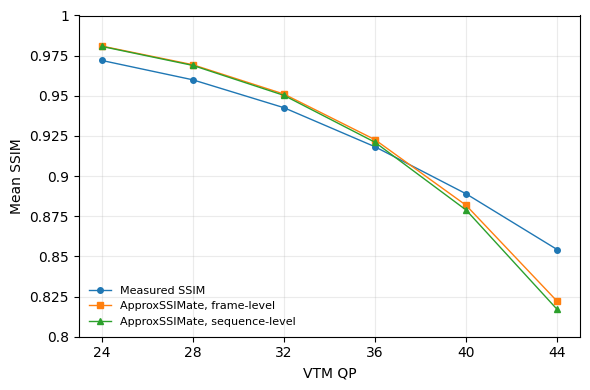

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    plot_df["qp"],
    plot_df["measured_ssim"],
    marker="o",
    markersize=4,
    linewidth=1,
    label="Measured SSIM",
)

ax.plot(
    plot_df["qp"],
    plot_df["approx_frame"],
    marker="s",
    markersize=4,
    linewidth=1,
    label="ApproxSSIMate, frame-level",
)

ax.plot(
    plot_df["qp"],
    plot_df["approx_pooled"],
    marker="^",
    markersize=4,
    linewidth=1,
    label="ApproxSSIMate, sequence-level",
)

ax.set_xlabel("VTM QP")
ax.set_ylabel("Mean SSIM")

ax.set_xticks(QPS)
ax.set_ylim(0.8, 1.0)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x:g}")
)

ax.grid(alpha=0.25)

ax.legend(
    loc="lower left",
    frameon=False,
    fontsize=8,
)

fig.tight_layout()
plt.show()

## 10. Approximation error distribution

Finally, we examine how the ApproxSSIMate error is distributed across individual sequences at each QP.

The error is defined as the estimated SSIM minus the measured SSIM. Each point represents one Objective-1-fast sequence, while the boxplot summarizes the distribution across all sequences for a given QP.

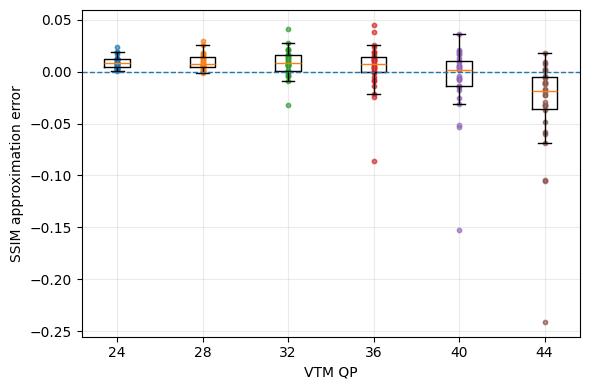

In [12]:
error_df = results_df.copy()

error_df["error"] = (
    error_df["approx_ssim"] - error_df["ssim"]
)

errors = [
    error_df.loc[error_df["qp"] == qp, "error"].values
    for qp in QPS
]

fig, ax = plt.subplots(figsize=(6, 4))

ax.boxplot(
    errors,
    positions=QPS,
    widths=1.2,
    showfliers=False,
)

for qp, values in zip(QPS, errors):
    ax.scatter(
        np.full(len(values), qp),
        values,
        s=10,
        alpha=0.7,
    )

ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel("VTM QP")
ax.set_ylabel("SSIM approximation error")

ax.set_xticks(QPS)
ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()